In [1]:
import pandas as pd
import seaborn as sns

ads = pd.read_csv("../Data/Social_Network_Ads.csv")

ads.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


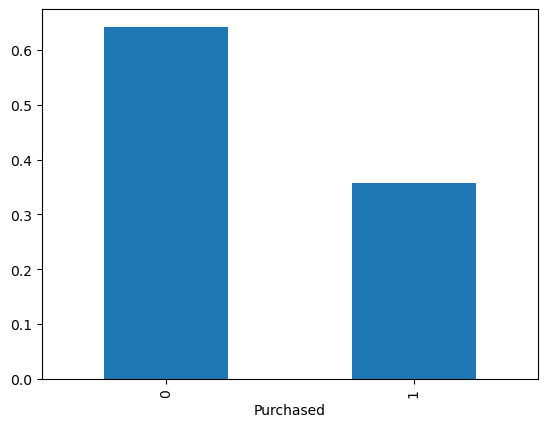

In [2]:
# Explore the target

ads["Purchased"].value_counts(normalize=True).plot.bar();

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Age', ylabel='Count'>

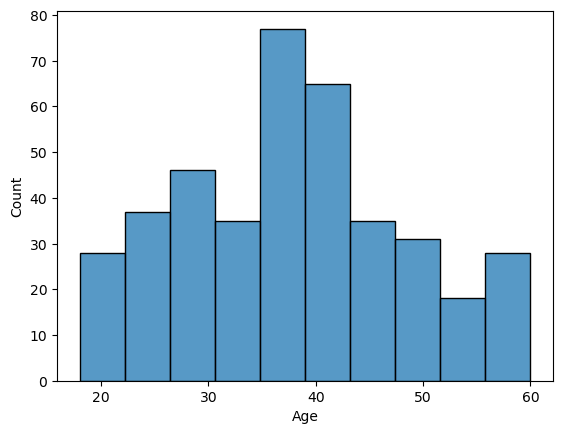

In [3]:
# explore the features

sns.histplot(ads["Age"])

<Axes: xlabel='Gender'>

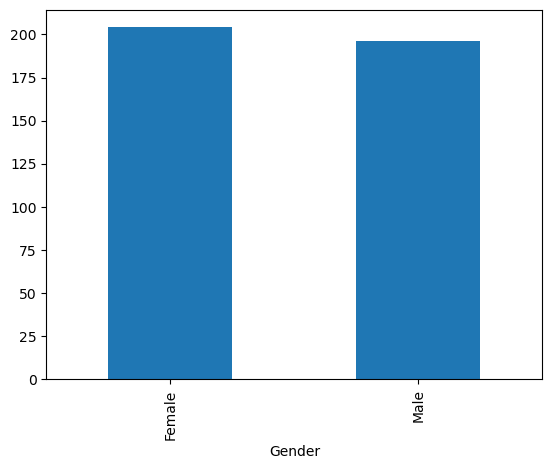

In [4]:
ads["Gender"].value_counts().plot.bar()

<Axes: >

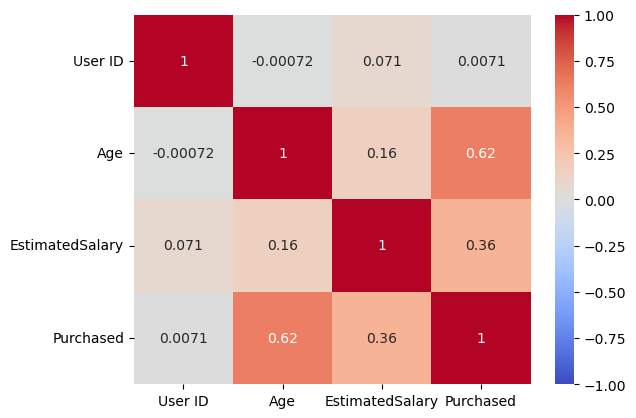

In [5]:
# Correlation MAtrix

sns.heatmap(
    ads.corr(numeric_only=True),
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    annot=True

)

<Axes: xlabel='Purchased', ylabel='Age'>

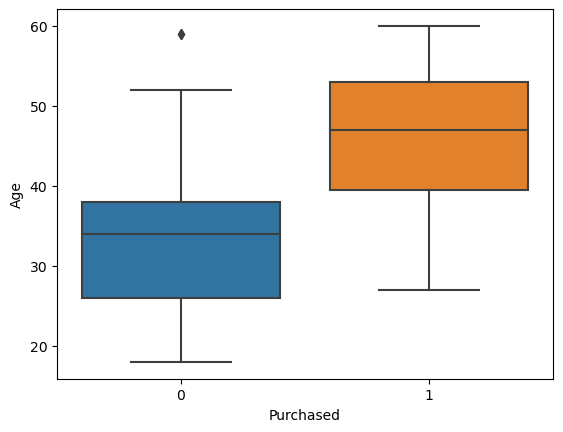

In [6]:
sns.boxplot(ads, x="Purchased", y="Age")

In [7]:
ads.groupby("Purchased")["Age"].mean()

Purchased
0    32.793774
1    46.391608
Name: Age, dtype: float64

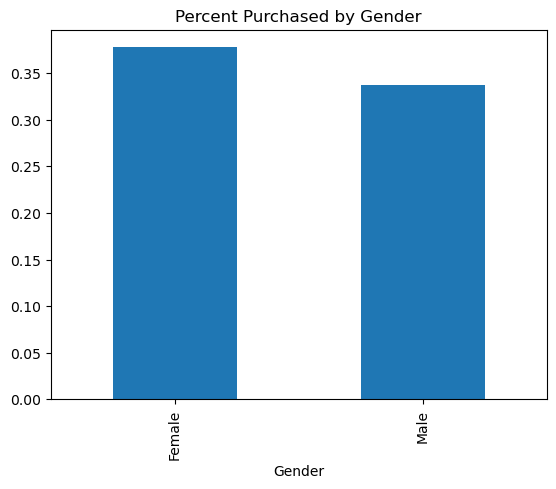

In [8]:
(ads
 .groupby("Gender")
 .agg({"Purchased": "mean"})
 .plot
 .bar(title="Percent Purchased by Gender", legend=False)
);

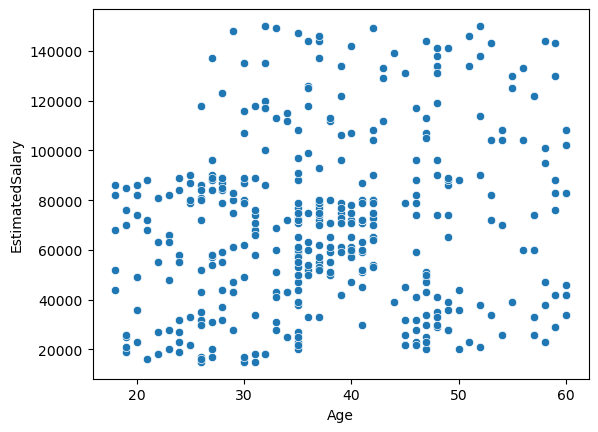

In [9]:
# Feature Feature relationships

sns.scatterplot(ads, x="Age", y="EstimatedSalary");

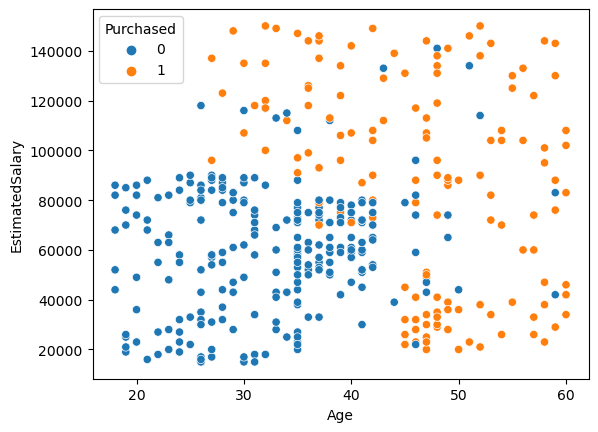

In [10]:
sns.scatterplot(data=ads, x="Age", y="EstimatedSalary", hue="Purchased");

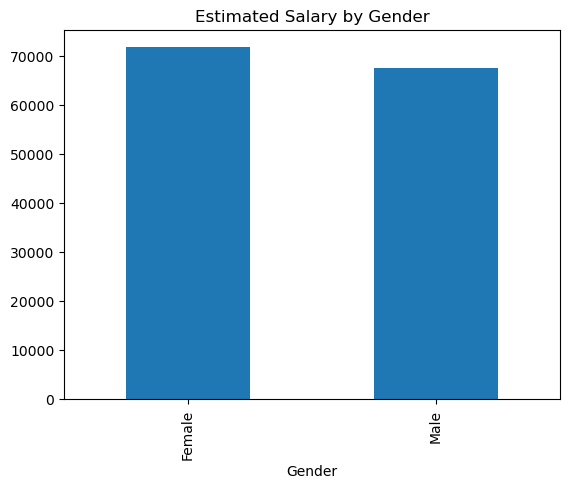

In [11]:
(ads
 .groupby("Gender")
 .agg({"EstimatedSalary": "mean"})
 .plot
 .bar(title="Estimated Salary by Gender", legend=False)
);

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


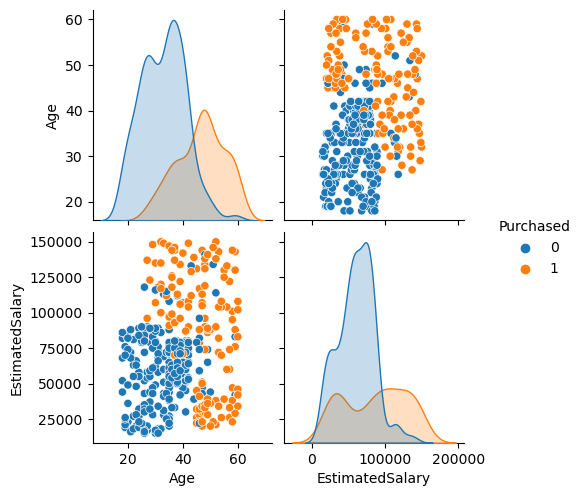

In [12]:
# pairplot 

sns.pairplot(ads.drop("User ID", axis=1), hue="Purchased");

## Feature Engineering

In [13]:
import numpy as np

ads = pd.get_dummies(
    ads.assign(
        age45 = np.where(ads["Age"] > 45, 1, 0),
        salary90 = np.where(ads["EstimatedSalary"] > 90000, 1, 0),
        agexsal = ads["Age"] * ads["EstimatedSalary"]
    ),
    drop_first=True
)
ads.head()

,User ID,Age,EstimatedSalary,Purchased,age45,salary90,agexsal,Gender_Male
0,15624510,19,19000,0,0,0,361000,True
1,15810944,35,20000,0,0,0,700000,True
2,15668575,26,43000,0,0,0,1118000,False
3,15603246,27,57000,0,0,0,1539000,False
4,15804002,19,76000,0,0,0,1444000,True


In [14]:
import pandas as pd

houses = pd.DataFrame({
    "PRICE": [399000, 99900, 539000, 299000, 320000, 699900, 295000, 245900, 480000, 375000, 770000],
    "BEDS": [3, 2, 3, 2, 2, 4, 3, 1, 5, 5, 3],
    "BATHS": [2, 1, 1, 1, 2, 3, 3, 1, 3, 2, 1]
})

houses

,PRICE,BEDS,BATHS
0,399000,3,2
1,99900,2,1
2,539000,3,1
3,299000,2,1
4,320000,2,2
5,699900,4,3
6,295000,3,3
7,245900,1,1
8,480000,5,3
9,375000,5,2


In [15]:
houses["total_rooms"] = houses["BEDS"] + houses["BATHS"]
houses["bed_bath_ratio"] = houses["BEDS"] / houses["BATHS"]
houses["bed_bath_interaction"] = houses["BEDS"] * houses["BATHS"]

houses

,PRICE,BEDS,BATHS,total_rooms,bed_bath_ratio,bed_bath_interaction
0,399000,3,2,5,1.500000,6
1,99900,2,1,3,2.000000,2
2,539000,3,1,4,3.000000,3
3,299000,2,1,3,2.000000,2
4,320000,2,2,4,1.000000,4
5,699900,4,3,7,1.333333,12
6,295000,3,3,6,1.000000,9
7,245900,1,1,2,1.000000,1
8,480000,5,3,8,1.666667,15
9,375000,5,2,7,2.500000,10


In [16]:
(houses - houses.mean()) / houses.std()

,PRICE,BEDS,BATHS,total_rooms,bed_bath_ratio,bed_bath_interaction
0,-0.061292,0.000000,0.208063,0.093720,-0.421741,-0.019342
1,-1.569570,-0.790569,-0.936282,-0.937203,0.240995,-0.870388
2,0.644689,0.000000,-0.936282,-0.421741,1.566467,-0.657627
3,-0.565564,-0.790569,-0.936282,-0.937203,0.240995,-0.870388
4,-0.459667,-0.790569,0.208063,-0.421741,-1.084477,-0.444865
5,1.456063,0.790569,1.352407,1.124643,-0.642653,1.257228
6,-0.585735,0.000000,1.352407,0.609182,-1.084477,0.618943
7,-0.833333,-1.581139,-0.936282,-1.452664,-1.084477,-1.083150
8,0.347168,1.581139,1.352407,1.640105,-0.200829,1.895512
9,-0.182317,1.581139,0.208063,1.124643,0.903731,0.831704


In [17]:
ads.columns

Index(['User ID', 'Age', 'EstimatedSalary', 'Purchased', 'age45', 'salary90',
       'agexsal', 'Gender_Male'],
      dtype='object')

In [18]:
from sklearn.model_selection import train_test_split

# Features ir target
X = ads[["Age", "EstimatedSalary", "Gender_Male"]]
y = ads["Purchased"]

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2023,
    stratify=y
)

print(f"Training Set Rows: {X_train.shape[0]}")
print(f"Test Set Rows: {X_test.shape[0]}")


Training Set Rows: 320
Test Set Rows: 80
